# Лабораторная работа №8: Кластеризация методом KMeans

### Импорт необходимых библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

### Загрузка данных

In [2]:
data = pd.read_csv('27_B_17834.csv', sep=';', decimal=',', encoding='utf-8')
X = data.values
print("Первые 5 строк данных:")
print(data.head())
print("\nРазмерность данных:", X.shape)

Первые 5 строк данных:
       X      Y
0  7.084  7.959
1 -0.759  5.781
2  6.736  4.640
3  7.899  7.361
4  0.297  5.932

Размерность данных: (9900, 2)


### Кластеризация методом KMeans

In [3]:
kmeans = KMeans(n_clusters=3, random_state=19, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f"Метки кластеров для первых 10 точек: {labels[:10]}")
print(f"Уникальные метки кластеров: {np.unique(labels)}")
print("\nКоординаты центроидов (средние):")
for i, center in enumerate(centroids):
    print(f"  Кластер {i+1}: ({center[0]:.6f}, {center[1]:.6f})")

Метки кластеров для первых 10 точек: [1 2 1 1 2 0 0 0 2 2]
Уникальные метки кластеров: [0 1 2]

Координаты центроидов (средние):
  Кластер 1: (4.112355, -0.485006)
  Кластер 2: (7.653017, 5.875096)
  Кластер 3: (0.430087, 5.023133)


### Визуализация результатов KMeans

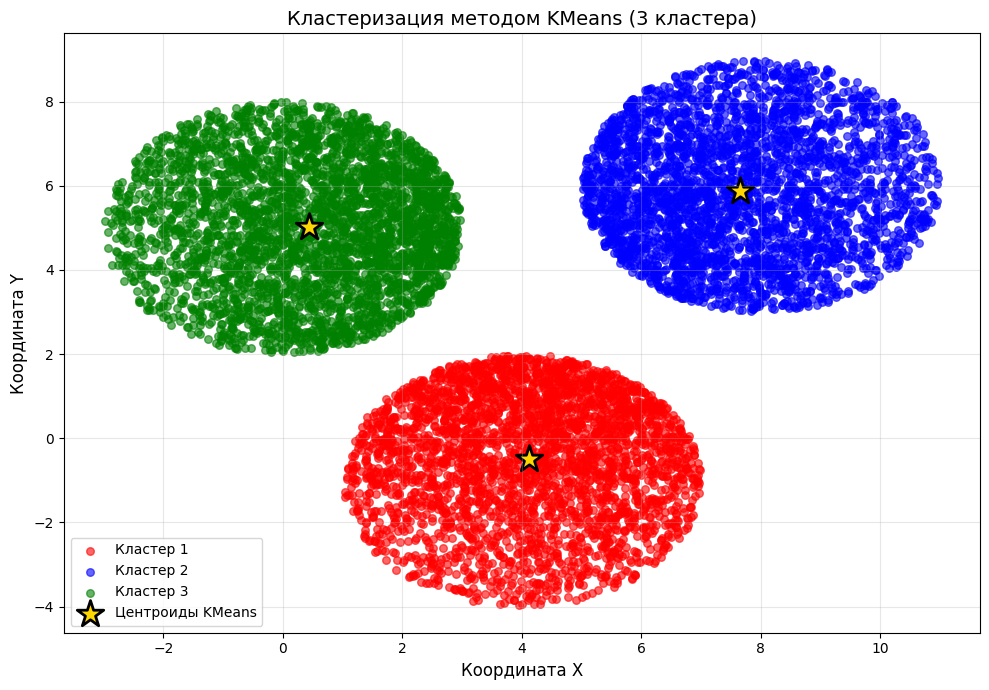

In [4]:
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], alpha=0.6, s=30, label=f'Кластер {i+1}')

plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='gold', marker='*', s=400, edgecolors='black', 
            linewidth=2, label='Центроиды KMeans')

plt.xlabel('Координата X', fontsize=12)
plt.ylabel('Координата Y', fontsize=12)
plt.title('Кластеризация методом KMeans (3 кластера)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Основные метрики KMeans

In [5]:
inertia = kmeans.inertia_
print("Основные результаты KMeans:")
print("=" * 50)
print(f"Инерция: {inertia:.2f}")
print(f"Количество итераций: {kmeans.n_iter_}")
print("\nРаспределение по кластерам:")
for i in range(3):
    cluster_size = np.sum(labels == i)
    print(f"  Кластер {i+1}: {cluster_size} точек ({cluster_size/len(X)*100:.1f}%)")

Основные результаты KMeans:
Инерция: 41227.08
Количество итераций: 3

Распределение по кластерам:
  Кластер 1: 3200 точек (32.3%)
  Кластер 2: 3200 точек (32.3%)
  Кластер 3: 3500 точек (35.4%)
